# 🌫️ Prediksi AQI 30 Hari ke Depan dengan LSTM Multivariate
### Kelompok 7 — Data Mining & Machine Learning


In [ ]:
# ============================================================
# SEL SETUP GOOGLE COLAB — Jalankan hanya jika di Colab
# Jika run lokal di VS Code / Jupyter, SKIP sel ini
# ============================================================
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Clone repo (skip jika sudah ada)
    if not os.path.exists("/content/daming-kelompok-7"):
        !git clone https://github.com/faizhuda/daming-kelompok-7.git
    
    # 2. Pindah ke root repo
    os.chdir("/content/daming-kelompok-7")
    
    # 3. Tambahkan root ke sys.path agar src/ bisa diimport
    if "/content/daming-kelompok-7" not in sys.path:
        sys.path.insert(0, "/content/daming-kelompok-7")
    
    # 4. Install dependencies
    !pip install -r requirements.txt -q
    
    print(f"Working dir : {os.getcwd()}")
    print(f"sys.path[0] : {sys.path[0]}")
    print("Setup Colab selesai!")
else:
    # Lokal: pastikan working dir di root repo (satu level di atas notebooks/)
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
    print(f"Mode lokal. Working dir: {os.getcwd()}")

## 1. Install Library & Import

In [1]:
import sys
import os
sys.path.insert(0, '..')   # insert di posisi 0 agar src/ diutamakan (bukan append)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

from src.utils import evaluate_model, log_experiment

## 2. Load Dataset

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Jalankan dari folder notebooks/ — path relatif ke root repo
df = pd.read_csv('../AQI Bangladesh.csv')

print(f"Shape    : {df.shape}")
print(f"Kolom    : {list(df.columns)}")
df.head()

Shape    : (1048551, 13)
Kolom    : ['city_id', 'city_name', 'lat', 'lon', 'datetime', 'pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0,16.7,252.0,NaN,18.6,5.2,13.0,50.0
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5,12.3,249.0,NaN,18.5,5.7,19.0,50.0
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1,10.9,244.0,NaN,18.4,6.5,27.0,51.0
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4,10.3,233.0,NaN,17.2,6.9,39.0,51.0
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8,11.3,217.0,NaN,14.8,6.2,51.0,51.0


In [3]:
# ── Info dataset ──────────────────────────────────────────────────────────────
print(df.dtypes)
print(f"\nMissing value:\n{df.isnull().sum()}")

city_id               int64
city_name               str
lat                 float64
lon                 float64
datetime                str
pm10                float64
pm2_5               float64
carbon_monoxide     float64
carbon_dioxide      float64
nitrogen_dioxide    float64
sulphur_dioxide     float64
ozone               float64
aqi                 float64
dtype: object

Missing value:
city_id                  0
city_name                0
lat                      0
lon                      0
datetime                 0
pm10                     0
pm2_5                    0
carbon_monoxide          0
carbon_dioxide      774327
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aqi                    696
dtype: int64


## 3. Exploratory Data Analysis (EDA)

EDA difokuskan pada hal-hal yang langsung relevan untuk LSTM:
tren AQI, distribusi, pola jam, dan korelasi antar fitur.

In [4]:
# ── Parse datetime ───────────────────────────────────────────────────────────
df['datetime'] = pd.to_datetime(df['datetime'])

pollutant_cols = ['pm10', 'pm2_5', 'carbon_monoxide',
                  'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

print(f"Rentang waktu : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Jumlah kota   : {df['city_name'].nunique()}")
print(f"Total record  : {len(df):,}")

Rentang waktu : 2000-01-01 00:00:00 → 2025-11-23 23:00:00
Jumlah kota   : 30
Total record  : 1,048,551


In [5]:
# ── Statistik deskriptif polutan + AQI ───────────────────────────────────────
df.describe()

,city_id,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
count,1.048551e+06,1.048551e+06,1.048551e+06,1048551,1.048551e+06,1.048551e+06,1.048551e+06,274224.000000,1.048551e+06,1.048551e+06,1.048551e+06,1.047855e+06
mean,1.724447e+06,2.368415e+01,9.048250e+01,2021-10-15 01:40:43.493163,7.497350e+01,5.067619e+01,3.235187e+02,456.900698,1.678140e+01,9.784067e+00,7.378080e+01,1.150751e+02
min,1.185100e+06,2.143973e+01,8.863779e+01,2000-01-01 00:00:00,2.000000e-01,1.000000e-01,1.000000e-01,408.000000,-1.000000e-01,0.000000e+00,-3.000000e+00,9.000000e+00
25%,1.185241e+06,2.301440e+01,9.006273e+01,2022-11-01 01:00:00,2.630000e+01,1.900000e+01,1.550000e+02,444.000000,4.400000e+00,2.900000e+00,4.500000e+01,6.800000e+01
50%,1.185263e+06,2.371040e+01,9.040744e+01,2023-11-01 17:00:00,5.610000e+01,3.990000e+01,2.720000e+02,452.000000,1.070000e+01,6.600000e+00,6.400000e+01,1.170000e+02
75%,1.209562e+06,2.407821e+01,9.097640e+01,2024-11-12 08:00:00,9.990000e+01,6.960000e+01,4.510000e+02,464.000000,2.440000e+01,1.420000e+01,9.400000e+01,1.572355e+02
max,7.921384e+06,2.567419e+01,9.221946e+01,2025-11-23 23:00:00,7.879000e+02,5.513000e+02,5.084000e+03,740.000000,1.780000e+02,1.724000e+02,3.280000e+02,2.995996e+02
std,1.702309e+06,9.928910e-01,8.652851e-01,NaN,6.744548e+01,4.186072e+01,2.804124e+02,20.958356,1.734989e+01,9.302039e+00,4.104232e+01,5.262795e+01


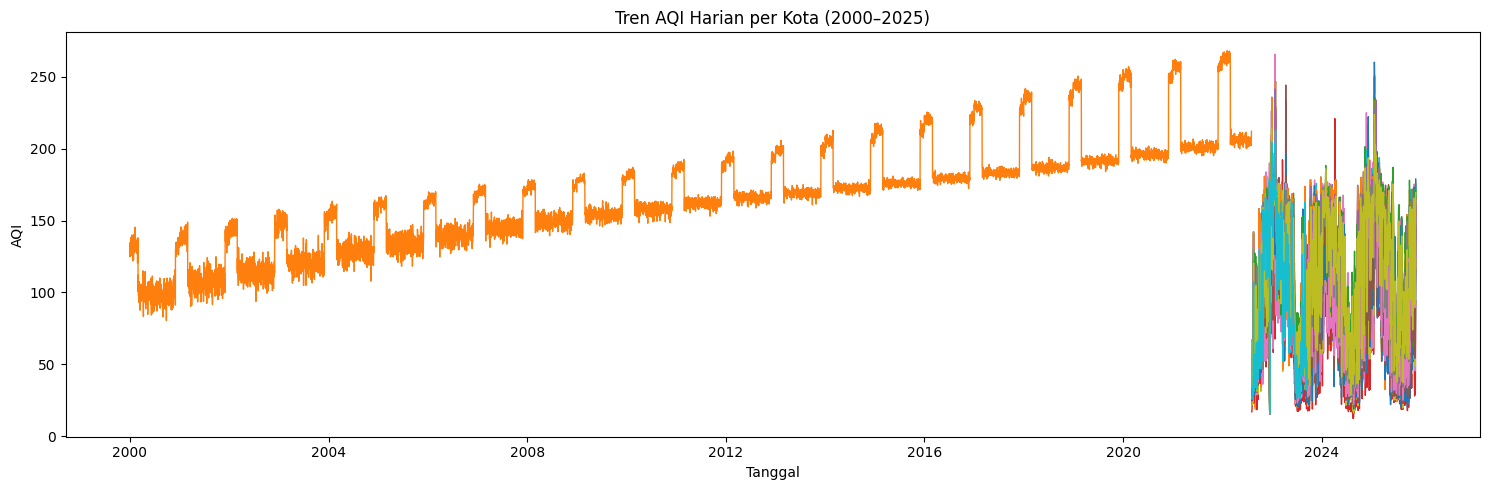

In [6]:
# ── Tren AQI harian per kota (EDA — tidak memodifikasi df) ───────────────────
# datetime sudah di-parse di sel sebelumnya (GwG2CoTs1Mb0)
df_ts = df.set_index('datetime')

daily_aqi = (
    df_ts.groupby('city_name')['aqi']
    .resample('D')
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 5))

for city in daily_aqi['city_name'].unique():
    d = daily_aqi[daily_aqi['city_name'] == city]
    ax.plot(d['datetime'], d['aqi'], linewidth=1)

ax.set_title('Tren AQI Harian per Kota (2000–2025)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('AQI')

plt.tight_layout()
plt.show()

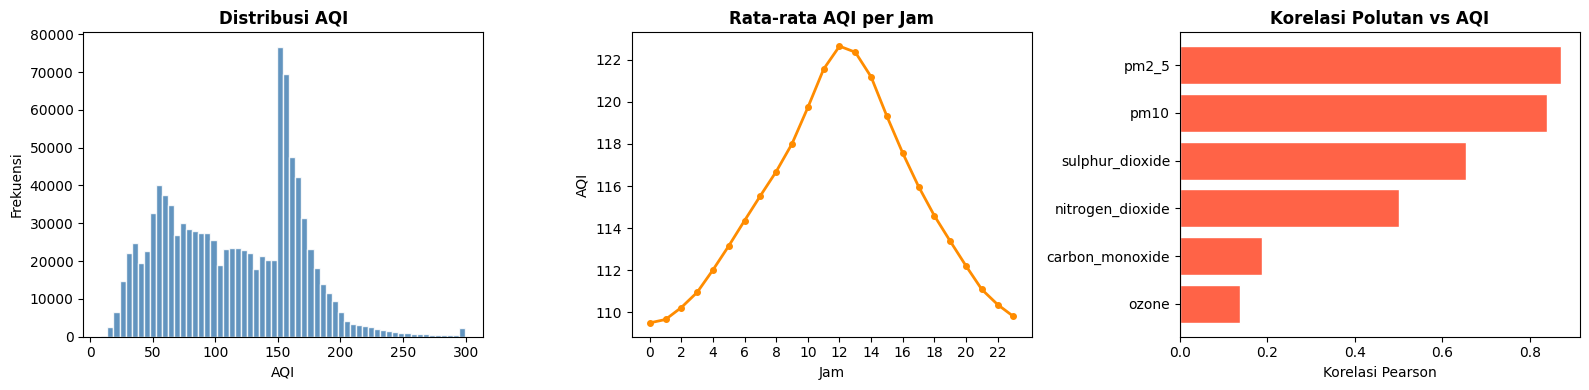

In [7]:
# ── Pola jam & distribusi ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribusi AQI
axes[0].hist(df['aqi'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi AQI', fontweight='bold')
axes[0].set_xlabel('AQI'); axes[0].set_ylabel('Frekuensi')

# Pola per jam
hourly = df.groupby(df['datetime'].dt.hour)['aqi'].mean()
axes[1].plot(hourly.index, hourly.values, color='darkorange', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Rata-rata AQI per Jam', fontweight='bold')
axes[1].set_xlabel('Jam'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(range(0, 24, 2))

# Korelasi polutan-AQI
corr = df[pollutant_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values()
bars = axes[2].barh(corr.index, corr.values,
                    color=['tomato' if v > 0 else 'steelblue' for v in corr.values],
                    edgecolor='white')
axes[2].set_title('Korelasi Polutan vs AQI', fontweight='bold')
axes[2].set_xlabel('Korelasi Pearson')
axes[2].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout(); plt.show()

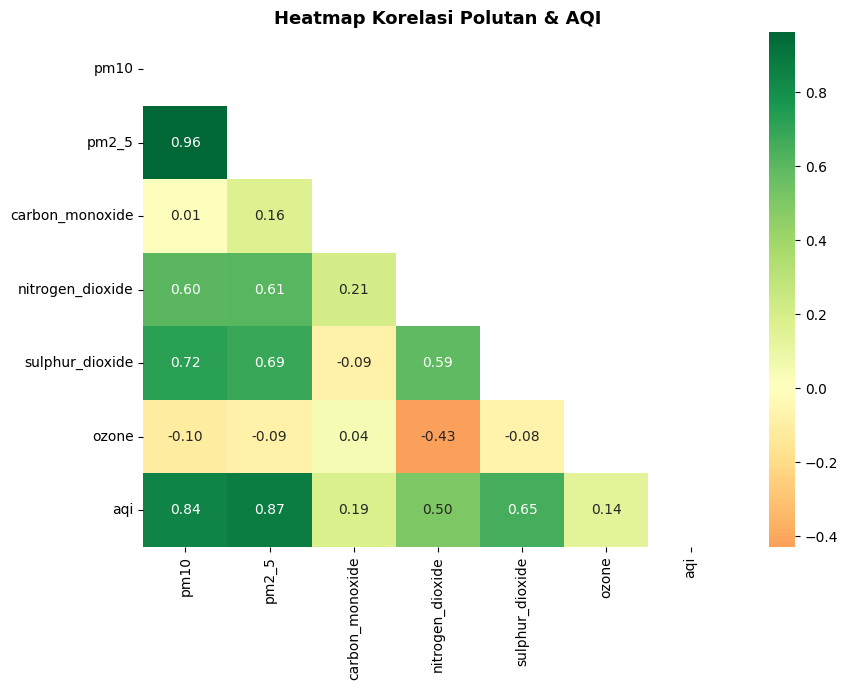

In [8]:
# ── Heatmap korelasi ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[pollutant_cols + ['aqi']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Heatmap Korelasi Polutan & AQI', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Data Cleaning

In [ ]:
# Cleaning: gunakan data 2015-2025 (10 tahun terakhir)
# Justifikasi: CV walk-forward menunjukkan data sebelum 2015 bersifat
# non-stationary (Fold 1 MAE=7.51 vs Fold 2-3 MAE<1.0). Data lama
# menambah noise daripada signal untuk kondisi polusi modern.
df_clean = df[df["datetime"].dt.year >= 2015].copy()

# Hapus kolom tak relevan jika ada
df_clean.drop(columns=["aqi_category"], errors="ignore", inplace=True)

# Parse datetime & urutkan
df_clean["datetime"] = pd.to_datetime(df_clean["datetime"])
df_clean.sort_values(["city_name", "datetime"], inplace=True)

# Hapus duplikasi
df_clean.drop_duplicates(subset=["city_id", "datetime"], inplace=True)

# Ganti nilai negatif jadi NaN
for col in pollutant_cols:
    df_clean.loc[df_clean[col] < 0, col] = float("nan")

print(f"Shape (2015-2025): {df_clean.shape}")
print(f"Rentang: {df_clean['datetime'].min()} s/d {df_clean['datetime'].max()}")

In [10]:
# Winsorizing outlier per kota
for col in pollutant_cols:
    q1 = df_clean.groupby('city_name')[col].transform(lambda x: x.quantile(0.01))
    q99 = df_clean.groupby('city_name')[col].transform(lambda x: x.quantile(0.99))
    df_clean[col] = df_clean[col].clip(q1, q99)

In [11]:
# ── Drop carbon_dioxide jika missing > 50% ───────────────────────────────────
if 'carbon_dioxide' in df_clean.columns:
    co2_missing = df_clean['carbon_dioxide'].isnull().mean() * 100
    print(f"carbon_dioxide missing: {co2_missing:.1f}%")
    if co2_missing > 50:
        df_clean = df_clean.drop(columns=['carbon_dioxide'])
        pollutant_cols = [c for c in pollutant_cols if c != 'carbon_dioxide']
        print("  → Kolom carbon_dioxide di-drop")

# ── Drop baris tanpa AQI target ───────────────────────────────────────────────
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=['aqi'])
print(f"Baris tanpa AQI dihapus : {n_before - len(df_clean):,}")

# ── Interpolasi linear per kota untuk polutan ────────────────────────────────
def interp_group(g):
    city = g.name
    g = g.set_index('datetime')
    numeric_cols = g.select_dtypes(include=[np.number]).columns
    g[numeric_cols] = g[numeric_cols].interpolate(method='time').bfill().ffill()
    g = g.reset_index()
    g['city_name'] = city
    return g

df_clean = df_clean.groupby('city_name', group_keys=False).apply(interp_group)
df_clean = df_clean.sort_values(['city_name','datetime']).reset_index(drop=True)
print(f"✅ Cleaning selesai. Shape: {df_clean.shape}")
print(f"   Missing setelah: {df_clean[pollutant_cols + ['aqi']].isnull().sum().sum()}\n")


carbon_dioxide missing: 63.1%
  → Kolom carbon_dioxide di-drop
Baris tanpa AQI dihapus : 0


✅ Cleaning selesai. Shape: (742551, 12)
   Missing setelah: 0



## 5. Feature Engineering

Fitur dibuat agar LSTM mendapat konteks temporal yang kaya:
- **Cyclical encoding** (hour, month, dayofweek)
- **Lag features** (1, 3, 6, 24 jam lalu)
- **Rolling statistics** (mean & std, window 3, 6, 24 jam)
- **Interaksi polutan** (pm_ratio, pm_total, oxidant_load, combustion_idx)

In [12]:
df_feat = df_clean.copy()

# ── Fitur temporal ────────────────────────────────────────────────────────────
df_feat['hour']       = df_feat['datetime'].dt.hour
df_feat['day']        = df_feat['datetime'].dt.day
df_feat['month']      = df_feat['datetime'].dt.month
df_feat['dayofweek']  = df_feat['datetime'].dt.dayofweek
df_feat['dayofyear']  = df_feat['datetime'].dt.dayofyear
df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
df_feat['quarter']    = df_feat['datetime'].dt.quarter

# Cyclical encoding (tidak ada urutan linear yang terputus)
df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']      / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']      / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month']     / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month']     / 12)
df_feat['dow_sin']   = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
df_feat['dow_cos']   = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

# Musim Bangladesh
def get_season(month):
    if month in [12,1,2]:      return 0  # winter
    elif month in [3,4,5]:     return 1  # pre_monsoon
    elif month in [6,7,8,9]:   return 2  # monsoon
    else:                      return 3  # post_monsoon
df_feat['season_code'] = df_feat['month'].apply(get_season)

print(f"Fitur temporal : {df_feat.shape[1] - df_clean.shape[1]} kolom baru")

Fitur temporal : 14 kolom baru


In [13]:
# ── Lag & Rolling features ────────────────────────────────────────────────────
lag_cols = pollutant_cols + ['aqi']

def create_lag_rolling(group):
    city = group.name
    group = group.sort_values('datetime')
    for col in lag_cols:
        for lag in [1, 3, 6, 24]:
            group[f'{col}_lag{lag}'] = group[col].shift(lag)
        for win in [3, 6, 24]:
            group[f'{col}_roll{win}m']   = group[col].shift(1).rolling(win, min_periods=1).mean()
            group[f'{col}_roll{win}std'] = group[col].shift(1).rolling(win, min_periods=1).std().fillna(0)
    group['city_name'] = city
    return group

print("Membuat fitur lag & rolling...")
df_feat = df_feat.groupby('city_name', group_keys=False).apply(create_lag_rolling)
print(f"Total kolom setelah lag/rolling: {df_feat.shape[1]}\n")


Membuat fitur lag & rolling...


Total kolom setelah lag/rolling: 96



In [14]:
# ── Interaksi polutan ─────────────────────────────────────────────────────────
# Untuk LSTM, interaksi dibuat dari nilai polutan waktu t (bukan lag1 seperti XGBoost)
# karena temporal dependency ditangani oleh sliding window LOOK_BACK.
#
# Definisi konsisten dengan CLAUDE.md dan src/features.py:
#   pm_ratio      = PM2.5 / (PM10 + ε)            — fraksi partikel halus
#   pm_total      = PM10 + PM2.5                   — beban partikel total
#   oxidant_load  = NO₂ + O₃                       — beban oksidan
#   combustion_idx = CO / (NO₂ + ε)               — indikator pembakaran tidak sempurna

eps = 1e-8
df_feat['pm_ratio']       = df_feat['pm2_5'] / (df_feat['pm10'] + eps)
df_feat['pm_total']       = df_feat['pm10'] + df_feat['pm2_5']
df_feat['oxidant_load']   = df_feat['nitrogen_dioxide'] + df_feat['ozone']
df_feat['combustion_idx'] = df_feat['carbon_monoxide'] / (df_feat['nitrogen_dioxide'] + eps)

# ── Drop lag NaN ──────────────────────────────────────────────────────────────
n_before = len(df_feat)
lag24_cols = [c for c in df_feat.columns if 'lag24' in c]
df_feat = df_feat.dropna(subset=lag24_cols).reset_index(drop=True)
print(f"Baris lag-NaN dihapus : {n_before - len(df_feat):,}")
print(f"Shape akhir           : {df_feat.shape}")

Baris lag-NaN dihapus : 720
Shape akhir           : (741831, 100)


In [15]:
# ── Label encoding city_name ──────────────────────────────────────────────────
le_city = LabelEncoder()
df_feat['city_encoded'] = le_city.fit_transform(df_feat['city_name'])
print(f"City mapping: {dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))}")

City mapping: {'Azimpur': np.int64(0), 'Badarganj': np.int64(1), 'Baniachang': np.int64(2), 'Barisāl': np.int64(3), 'Bera': np.int64(4), 'Bhairab Bāzār': np.int64(5), 'Bherāmāra': np.int64(6), 'Bhola': np.int64(7), 'Bhāndāria': np.int64(8), 'Bhātpāra Abhaynagar': np.int64(9), 'Bogra': np.int64(10), 'Burhānuddin': np.int64(11), 'Bājitpur': np.int64(12), 'Bāndarban': np.int64(13), 'Char Bhadrāsan': np.int64(14), 'Chhāgalnāiya': np.int64(15), 'Chhātak': np.int64(16), 'Chilmāri': np.int64(17), 'Chittagong': np.int64(18), 'Comilla': np.int64(19), 'Cox’s Bāzār': np.int64(20), 'Dhaka': np.int64(21), 'Dinājpur': np.int64(22), 'Dohār': np.int64(23), 'Farīdpur': np.int64(24), 'Fatikchari': np.int64(25), 'Feni': np.int64(26), 'Gafargaon': np.int64(27), 'Gaibandha': np.int64(28), 'Gaurnadi': np.int64(29)}


## 6. Persiapan Data untuk LSTM

### Strategi:
- **Data**: semua kota (multi-city global model), 6 bulan terakhir untuk feasibility
- **Granularitas**: per jam (hourly) — fitur lag & cyclical tetap bermakna
- **Split**: 80% train / 20% test (**time-aware** — sort by datetime, bukan by city)
- **Forecasting horizon**: 30 hari = 720 jam

In [16]:
# ── Gunakan 6 bulan terakhir (semua kota) ────────────────────────────────────
cutoff = df_feat['datetime'].max() - pd.DateOffset(months=6)

df_city = (
    df_feat[df_feat['datetime'] >= cutoff]
    .reset_index(drop=True)
)

# Kota dengan data terbanyak (untuk labeling visualisasi)
top_city = df_city.groupby('city_name').size().idxmax()

print(f"Rentang      : {df_city['datetime'].min()} → {df_city['datetime'].max()}")
print(f"Total record : {len(df_city):,}")
print(f"Jumlah kota  : {df_city['city_name'].nunique()}")
print(f"Top city     : {top_city} (digunakan untuk label visualisasi)")

Rentang      : 2025-05-23 23:00:00 → 2025-11-23 23:00:00
Total record : 128,093
Jumlah kota  : 29
Top city     : Azimpur (digunakan untuk label visualisasi)


In [17]:
# ── Definisi fitur ────────────────────────────────────────────────────────────
COLS_EXCLUDE = ['datetime','city_id','city_name','lat','lon','aqi',
                'aqi_category','year']
TARGET = 'aqi'

FEATURES = [c for c in df_city.columns
            if c not in COLS_EXCLUDE
            and df_city[c].dtype in ['float64','int64','int32','int8','uint8']]

print(f"Jumlah fitur : {len(FEATURES)}")
print(f"Target       : {TARGET}")

# Drop baris dengan NaN di fitur/target
df_model = df_city[FEATURES + [TARGET, 'datetime']].dropna().reset_index(drop=True)
print(f"Record bersih: {len(df_model):,}")

Jumlah fitur : 95
Target       : aqi
Record bersih: 128,093


In [18]:
# ── Time-aware split 80/20 ────────────────────────────────────────────────────
# PENTING: sort by datetime (bukan city_name) agar split benar-benar kronologis
df_model = df_model.sort_values('datetime').reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)
train_df  = df_model.iloc[:split_idx].copy()
test_df   = df_model.iloc[split_idx:].copy()

print(f"Train : {len(train_df):,} record  ({train_df['datetime'].min().date()} → {train_df['datetime'].max().date()})")
print(f"Test  : {len(test_df):,}  record  ({test_df['datetime'].min().date()} → {test_df['datetime'].max().date()})")

Train : 102,474 record  (2025-05-23 → 2025-10-18)
Test  : 25,619  record  (2025-10-18 → 2025-11-23)


In [19]:
# ── Scaling ────────────────────────────────────────────────────────────────────
# RobustScaler untuk fitur (tahan outlier)
# MinMaxScaler untuk target AQI agar LSTM konvergen lebih stabil

binary_cols = [c for c in FEATURES if df_model[c].nunique() <= 2]
scale_cols  = [c for c in FEATURES if c not in binary_cols]

scaler_X = RobustScaler()
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train = train_df[FEATURES].values.copy()
X_test  = test_df[FEATURES].values.copy()
y_train = train_df[TARGET].values.reshape(-1, 1)
y_test  = test_df[TARGET].values.reshape(-1, 1)

# Indeks kolom yang perlu di-scale
scale_idx = [FEATURES.index(c) for c in scale_cols]
X_train[:, scale_idx] = scaler_X.fit_transform(X_train[:, scale_idx])
X_test[:, scale_idx]  = scaler_X.transform(X_test[:, scale_idx])

y_train_sc = scaler_y.fit_transform(y_train).flatten()
y_test_sc  = scaler_y.transform(y_test).flatten()

print(f"✅ Scaling selesai")
print(f"   X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"   y_train : {y_train_sc.shape}  |  y_test : {y_test_sc.shape}")

✅ Scaling selesai
   X_train : (102474, 95)  |  X_test : (25619, 95)
   y_train : (102474,)  |  y_test : (25619,)


## 7. Membuat Sequence LSTM (Sliding Window)

LSTM membutuhkan input dalam bentuk sequence `(samples, timesteps, features)`.

**LOOK_BACK = 48 jam** (2 hari) → LSTM melihat 48 jam terakhir untuk memprediksi 1 jam berikutnya.

> Kenapa 48? AQI memiliki pola harian (24 jam) dan pengaruh multi-hari dari kondisi cuaca.
> 48 jam mencakup 2 siklus harian sekaligus — cukup untuk menangkap pola tanpa terlalu berat di memori.

In [ ]:
LOOK_BACK = 48  # 2 hari x 24 jam = 48 jam

def make_sequences(X, y, look_back):
    """
    Buat sliding window sequence.
    Input  : X (N, features), y (N,)
    Output : Xs (N-look_back, look_back, features), ys (N-look_back,)
    Menggunakan float16 untuk menghemat RAM (~50% vs float32).
    """
    Xs, ys = [], []
    for i in range(look_back, len(X)):
        Xs.append(X[i - look_back:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float16), np.array(ys, dtype=np.float32)

X_seq_tr, y_seq_tr = make_sequences(X_train, y_train_sc, LOOK_BACK)

# Untuk test: sambung ekor train agar sequence pertama valid
X_combined = np.concatenate([X_train, X_test], axis=0)
y_combined  = np.concatenate([y_train_sc, y_test_sc], axis=0)
X_seq_all, y_seq_all = make_sequences(X_combined, y_combined, LOOK_BACK)
X_seq_te = X_seq_all[-len(y_test_sc):]
y_seq_te = y_seq_all[-len(y_test_sc):]

n_features = X_seq_tr.shape[2]

print(f"LOOK_BACK      : {LOOK_BACK} jam ({LOOK_BACK // 24} hari)")
print(f"n_features     : {n_features}")
print(f"X_seq_tr shape : {X_seq_tr.shape}  (float16 ~ {X_seq_tr.nbytes/1e9:.2f} GB)")
print(f"X_seq_te shape : {X_seq_te.shape}")
print(f"y_seq_tr shape : {y_seq_tr.shape}")

## 8. Arsitektur LSTM

**Desain:** 3-layer Bidirectional LSTM + BatchNormalization + Dropout

| Layer | Unit | Keterangan |
|---|---|---|
| BiLSTM 1 | 128×2 | Tangkap pola maju & mundur |
| BiLSTM 2 | 64×2  | Abstraksi lebih dalam |
| LSTM 3   | 32    | Reduksi ke representasi akhir |
| Dense    | 16    | Non-linear projection |
| Output   | 1     | Prediksi AQI (skala 0–1) |

**Bidirectional LSTM** dipilih karena pada fase training, model dapat belajar dari konteks dua arah, sehingga representasi internal yang terbentuk lebih kaya.


In [21]:
tf.random.set_seed(42)
np.random.seed(42)

def build_lstm_model(look_back, n_features, learning_rate=1e-3):
    model = Sequential([
        # Layer 1: Bidirectional LSTM — tangkap pola dari dua arah
        Bidirectional(LSTM(128, return_sequences=True),
                      input_shape=(look_back, n_features)),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2: Bidirectional LSTM — abstraksi lebih dalam
        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.2),

        # Layer 3: LSTM terakhir — hasilkan representasi sequence
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        # Dense head
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # sigmoid → output dalam [0,1] sesuai MinMaxScaler
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss='huber',             # robust terhadap outlier AQI ekstrem
        metrics=['mae']
    )
    return model

lstm_model = build_lstm_model(LOOK_BACK, n_features)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       229,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 48, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,601 (1.59 MB)

 Trainable params: 416,769 (1.59 MB)

 Non-trainable params: 832 (3.25 KB)

## 9. Training LSTM

In [22]:
# ── Buat direktori output ──────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'models/best_lstm_aqi.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("✅ Callbacks siap:")
print("   EarlyStopping    : patience=12, restore best weights")
print("   ReduceLROnPlateau: factor=0.4, patience=6")
print("   ModelCheckpoint  : simpan model terbaik ke 'models/best_lstm_aqi.h5'")

✅ Callbacks siap:
   EarlyStopping    : patience=12, restore best weights
   ReduceLROnPlateau: factor=0.4, patience=6
   ModelCheckpoint  : simpan model terbaik ke 'models/best_lstm_aqi.h5'


In [23]:
# ── Training ────────────────────────────────────────────────────────────────
history = lstm_model.fit(
    X_seq_tr, y_seq_tr,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    shuffle=False,   # PENTING: jangan shuffle untuk time-series
    verbose=1
)

print(f"\n✅ Training selesai pada epoch {len(history.history['loss'])}")

Epoch 1/25


   1/1361 ━━━━━━━━━━━━━━━━━━━━ 10:13:24 27s/step - loss: 0.0251 - mae: 0.1839

   2/1361 ━━━━━━━━━━━━━━━━━━━━ 3:21 148ms/step - loss: 0.0265 - mae: 0.1893  

   3/1361 ━━━━━━━━━━━━━━━━━━━━ 3:20 148ms/step - loss: 0.0265 - mae: 0.1877

   4/1361 ━━━━━━━━━━━━━━━━━━━━ 3:17 146ms/step - loss: 0.0262 - mae: 0.1854

...


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00016000000759959222.


1361/1361 ━━━━━━━━━━━━━━━━━━━━ 146s 107ms/step - loss: 0.0060 - mae: 0.0831 - val_loss: 0.0442 - val_mae: 0.2385 - learning_rate: 4.0000e-04


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 1.



✅ Training selesai pada epoch 13


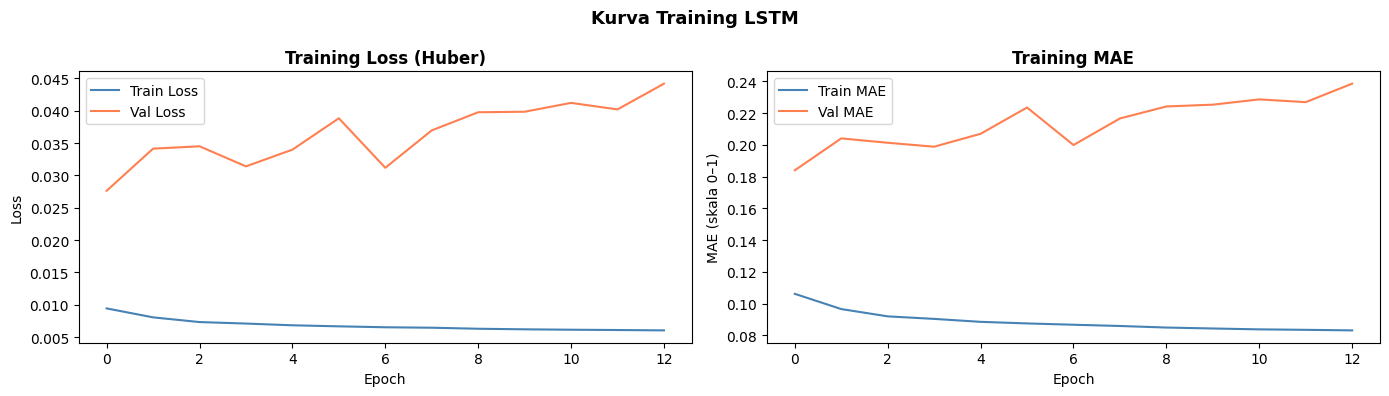

In [24]:
# ── Plot Training & Validation Loss ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral',     linewidth=1.5)
axes[0].set_title('Training Loss (Huber)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='coral',     linewidth=1.5)
axes[1].set_title('Training MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (skala 0–1)')
axes[1].legend()

plt.suptitle('Kurva Training LSTM', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 10. Evaluasi Model pada Data Test

Evaluasi dilakukan pada **data test (20% akhir)** — data yang tidak pernah dilihat model selama training.


In [25]:
# ── Prediksi test set ─────────────────────────────────────────────────────────
y_pred_sc = lstm_model.predict(X_seq_te, batch_size=64, verbose=0).flatten()

# Inverse transform ke skala AQI asli
y_pred_orig = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).flatten()
y_true_orig = scaler_y.inverse_transform(y_seq_te.reshape(-1, 1)).flatten()

# Clip agar tidak negatif
y_pred_orig = np.clip(y_pred_orig, 0, None)

print(f"Sampel prediksi : {len(y_pred_orig):,}")

Sampel prediksi : 25,619


In [26]:
# ── Hitung metrik via evaluate_model (konsisten dengan src/utils.py) ──────────
test_metrics = evaluate_model(y_true_orig, y_pred_orig, "LSTM-Bidirectional")

print("=" * 50)
print("   EVALUASI LSTM — DATA TEST")
print("=" * 50)
for k, v in test_metrics.items():
    if k == 'Model':
        continue
    unit = '%' if k == 'MAPE' else ''
    print(f"   {k:<8} : {v:.4f}{unit}")
print("=" * 50)

# ── Log experiment ke CSV (konsisten dengan workflow nb05) ────────────────────
lstm_params = {
    "look_back": LOOK_BACK,
    "layers": "BiLSTM(128)+BiLSTM(64)+LSTM(32)",
    "loss": "huber",
    "optimizer": "adam",
    "data_months": 6,
}
log_experiment(
    model_name="LSTM-Bidirectional",
    params=lstm_params,
    metrics=test_metrics,
    log_path="results/experiment_log.csv",
)
print("\n✅ Hasil dicatat ke results/experiment_log.csv")

   EVALUASI LSTM — DATA TEST
   MAE      : 55.8052
   RMSE     : 65.3592
   R2       : -2.0840
   MAPE     : 42.3920%

✅ Hasil dicatat ke results/experiment_log.csv


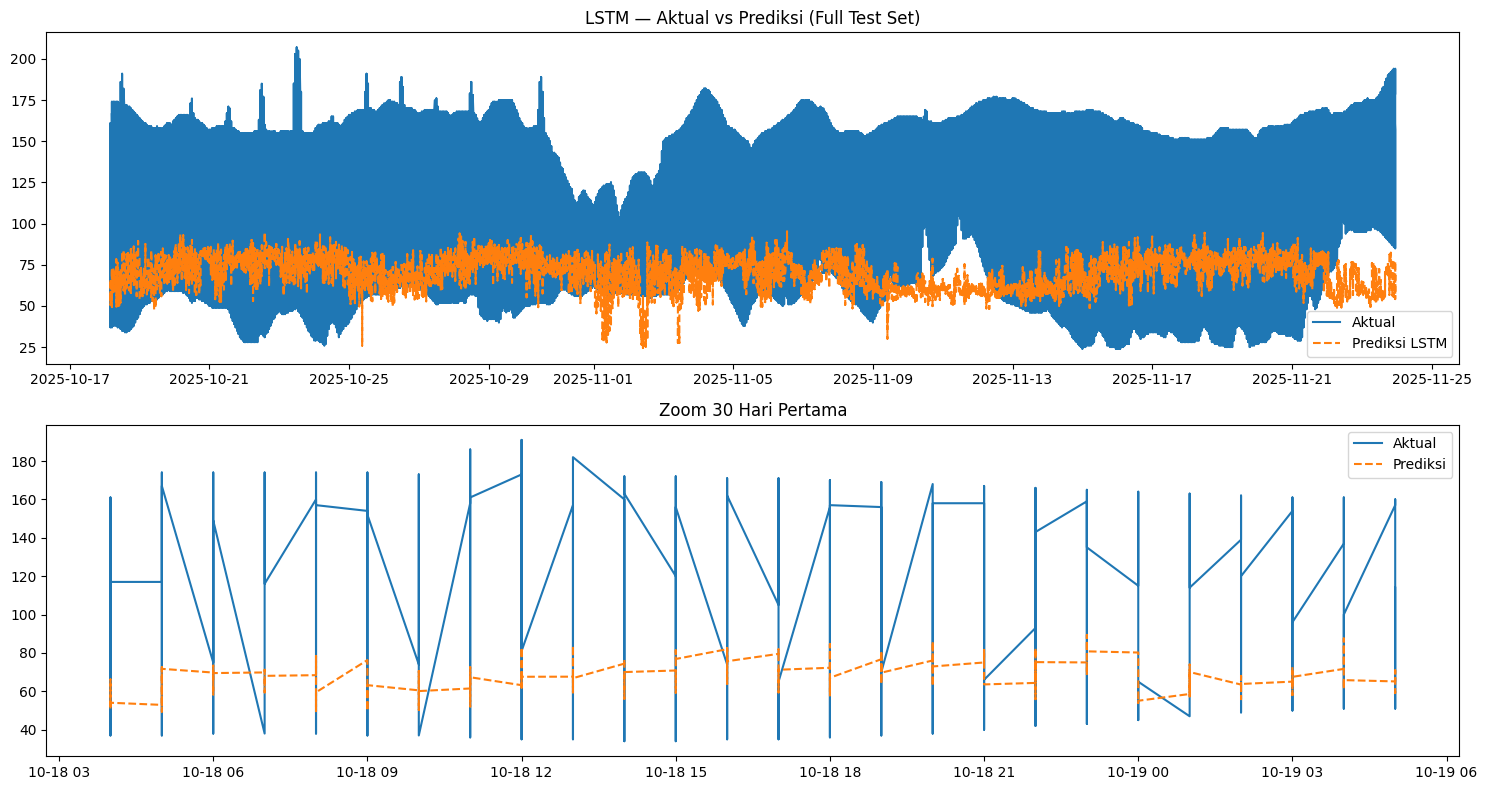

In [27]:
test_dates = test_df['datetime'].values

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Full test set
axes[0].plot(test_dates, y_true_orig, label='Aktual')
axes[0].plot(test_dates, y_pred_orig, label='Prediksi LSTM', linestyle='--')

axes[0].set_title('LSTM — Aktual vs Prediksi (Full Test Set)')
axes[0].legend()

# Zoom 30 hari
zoom_n = min(30 * 24, len(y_true_orig))

axes[1].plot(test_dates[:zoom_n], y_true_orig[:zoom_n], label='Aktual')
axes[1].plot(test_dates[:zoom_n], y_pred_orig[:zoom_n],
             label='Prediksi', linestyle='--')

axes[1].legend()
axes[1].set_title('Zoom 30 Hari Pertama')

plt.tight_layout()
plt.show()

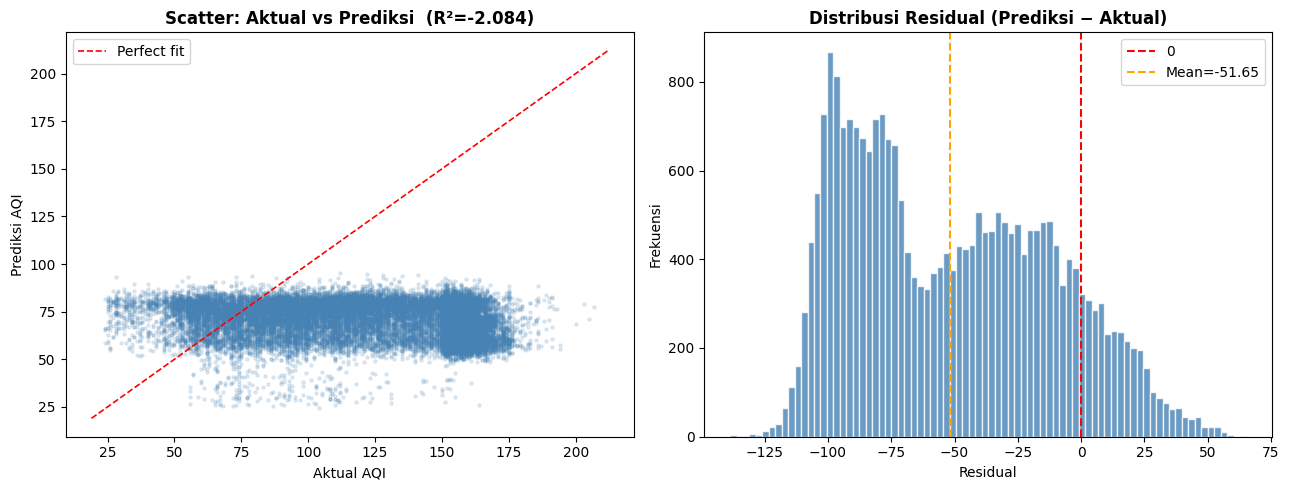

In [28]:
# ── Scatter plot & residual ───────────────────────────────────────────────────
r2_val = test_metrics['R2']   # ambil dari evaluate_model result

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.15, s=5, color='steelblue')
lims = [min(y_true_orig.min(), y_pred_orig.min()) - 5,
        max(y_true_orig.max(), y_pred_orig.max()) + 5]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_title(f'Scatter: Aktual vs Prediksi  (R²={r2_val:.3f})', fontweight='bold')
axes[0].set_xlabel('Aktual AQI'); axes[0].set_ylabel('Prediksi AQI')
axes[0].legend()

# Residual distribution
residuals = y_pred_orig - y_true_orig
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,               color='red',    linewidth=1.5, linestyle='--', label='0')
axes[1].axvline(residuals.mean(),color='orange', linewidth=1.5, linestyle='--',
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_title('Distribusi Residual (Prediksi − Aktual)', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout(); plt.show()

In [29]:
# ── Analisis kesalahan per level AQI ─────────────────────────────────────────
def aqi_category(v):
    if v <= 50:   return '0–50 Good'
    elif v <= 100: return '51–100 Moderate'
    elif v <= 150: return '101–150 Unhealthy (Sensitive)'
    elif v <= 200: return '151–200 Unhealthy'
    else:          return '>200 Very Unhealthy'

err_df = pd.DataFrame({'actual': y_true_orig, 'pred': y_pred_orig})
err_df['category'] = err_df['actual'].apply(aqi_category)
err_df['abs_err']  = np.abs(err_df['actual'] - err_df['pred'])

cat_err = err_df.groupby('category').agg(
    Count=('abs_err','count'),
    MAE=('abs_err','mean'),
    MaxErr=('abs_err','max')
).sort_index()

print("\nAnalisis Error per Kategori AQI:")
print(cat_err.round(3).to_string())


Analisis Error per Kategori AQI:
                               Count         MAE      MaxErr
category                                                    
0–50 Good                        674   34.191002   65.306999
101–150 Unhealthy (Sensitive)   7901   52.498001  118.627998
151–200 Unhealthy               9544   91.804001  138.645996
51–100 Moderate                 7497   15.377000   73.699997
>200 Very Unhealthy                3  129.246002  134.028000


## 11. Forecasting AQI 30 Hari ke Depan

### Strategi: Multi-Step Recursive Forecasting

Karena kita butuh prediksi **720 langkah ke depan** (30 hari × 24 jam), kita pakai strategi **recursive/autoregressive**:

1. Ambil **LOOK_BACK (48) jam terakhir** dari data historis sebagai seed sequence
2. Prediksi jam ke-1 → hasilnya masuk ke sequence
3. Prediksi jam ke-2 menggunakan sequence yang sudah diupdate
4. Ulangi hingga 720 jam

**Catatan:** Fitur polutan yang tidak diketahui di masa depan diisi dengan **nilai terakhir yang diketahui** (carry-forward) — asumsi kondisi polutan stabil. Fitur temporal (hour_sin/cos, dll) diisi secara tepat berdasarkan timestamp masa depan.

In [30]:
FORECAST_HOURS = 30 * 24  # 720 jam

# ── Seed: LOOK_BACK jam terakhir dari seluruh data (train + test) ─────────────
X_all = np.concatenate([X_train, X_test], axis=0)
seed_sequence = X_all[-LOOK_BACK:].copy()   # (LOOK_BACK, n_features) = (48, n_features)

# Mapping nama fitur ke indeks
feat_idx = {f: i for i, f in enumerate(FEATURES)}

# ── Helper: buat fitur temporal untuk timestamp tertentu ─────────────────────
def temporal_features_for(ts):
    """
    Return dict berisi nilai fitur temporal untuk timestamp ts (pd.Timestamp).
    """
    h = ts.hour; m = ts.month; dow = ts.dayofweek

    def get_season(month):
        if month in [12,1,2]:     return 0
        elif month in [3,4,5]:    return 1
        elif month in [6,7,8,9]:  return 2
        else:                     return 3

    return {
        'hour':       h,
        'day':        ts.day,
        'month':      m,
        'dayofweek':  dow,
        'dayofyear':  ts.dayofyear,
        'is_weekend': int(dow >= 5),
        'quarter':    ts.quarter,
        'hour_sin':   np.sin(2*np.pi*h/24),
        'hour_cos':   np.cos(2*np.pi*h/24),
        'month_sin':  np.sin(2*np.pi*m/12),
        'month_cos':  np.cos(2*np.pi*m/12),
        'dow_sin':    np.sin(2*np.pi*dow/7),
        'dow_cos':    np.cos(2*np.pi*dow/7),
        'season_code': get_season(m),
    }

print(f"Forecast horizon : {FORECAST_HOURS} jam = 30 hari")
print(f"Seed sequence    : {seed_sequence.shape}  ({LOOK_BACK} jam × {n_features} fitur)")

Forecast horizon : 720 jam = 30 hari
Seed sequence    : (48, 95)  (48 jam × 95 fitur)


In [31]:
# ── Recursive Forecasting ─────────────────────────────────────────────────────
last_known_dt  = df_model['datetime'].iloc[-1]
forecast_aqi   = []
current_seq    = seed_sequence.copy()   # (LOOK_BACK, n_features) = (48, n_features)

# Nilai fitur non-temporal terakhir (carry-forward untuk polutan dll)
last_row = X_all[-1].copy()

print(f"Mulai dari     : {last_known_dt}")
print(f"Prediksi hingga: {last_known_dt + pd.Timedelta(hours=FORECAST_HOURS)}")
print("\nForecasting...")

for step in range(FORECAST_HOURS):
    # (1) Prediksi 1 langkah ke depan
    input_3d   = current_seq[np.newaxis, :, :]   # (1, LOOK_BACK, n_features)
    pred_scaled = lstm_model.predict(input_3d, verbose=0)[0, 0]
    pred_aqi   = float(scaler_y.inverse_transform([[pred_scaled]])[0, 0])
    pred_aqi   = max(0, pred_aqi)
    forecast_aqi.append(pred_aqi)

    # (2) Bangun baris fitur baru untuk timestamp berikutnya
    next_ts   = last_known_dt + pd.Timedelta(hours=step + 1)
    new_row   = last_row.copy()

    # Update fitur temporal
    tf_vals   = temporal_features_for(next_ts)
    for fname, fval in tf_vals.items():
        if fname in feat_idx:
            new_row[feat_idx[fname]] = fval

    # Update lag-1 AQI dengan prediksi saat ini (scaled)
    for lag_name in ['aqi_lag1']:
        if lag_name in feat_idx:
            new_row[feat_idx[lag_name]] = pred_scaled

    # Geser sequence: drop baris terlama, tambah baris baru
    current_seq = np.vstack([current_seq[1:], new_row])

    if (step + 1) % 120 == 0:
        print(f"  Step {step+1}/{FORECAST_HOURS} | AQI pred: {pred_aqi:.1f}")

print(f"\n✅ Forecasting selesai — {len(forecast_aqi)} prediksi")

Mulai dari     : 2025-11-23 23:00:00
Prediksi hingga: 2025-12-23 23:00:00

Forecasting...


  Step 120/720 | AQI pred: 84.7


  Step 240/720 | AQI pred: 74.2


  Step 360/720 | AQI pred: 74.0


  Step 480/720 | AQI pred: 75.0


  Step 600/720 | AQI pred: 61.4


  Step 720/720 | AQI pred: 62.5

✅ Forecasting selesai — 720 prediksi


In [32]:
# ── Buat dataframe hasil forecast ─────────────────────────────────────────────
forecast_dates = pd.date_range(
    start=last_known_dt + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq='h'   # lowercase 'h' — 'H' deprecated sejak pandas 2.2
)

df_forecast = pd.DataFrame({
    'datetime': forecast_dates,
    'aqi_pred': forecast_aqi
})

# Agregasi harian
df_forecast['date'] = df_forecast['datetime'].dt.date
df_daily_forecast   = df_forecast.groupby('date').agg(
    aqi_mean=('aqi_pred', 'mean'),
    aqi_min=('aqi_pred', 'min'),
    aqi_max=('aqi_pred', 'max'),
    aqi_std=('aqi_pred', 'std')
).reset_index()

df_daily_forecast['date'] = pd.to_datetime(df_daily_forecast['date'])

print(f"Periode forecast : {df_daily_forecast['date'].min().date()} → {df_daily_forecast['date'].max().date()}")
print(f"\nForecast 30 Hari (Harian):")
print(df_daily_forecast.round(2).to_string(index=False))

Periode forecast : 2025-11-24 → 2025-12-23

Forecast 30 Hari (Harian):
      date  aqi_mean  aqi_min  aqi_max  aqi_std
2025-11-24     58.58    48.56    70.87     5.79
2025-11-25     72.80    58.99    78.40     5.20
2025-11-26     91.35    87.29    92.63     1.19
2025-11-27     91.68    88.79    92.95     1.02
2025-11-28     89.52    84.07    92.65     3.21
2025-11-29     75.18    72.42    84.03     2.64
2025-11-30     74.69    73.72    75.88     0.68
2025-12-01     58.04    53.55    75.41     7.46
2025-12-02     69.86    55.14    76.60     6.61
2025-12-03     73.63    70.95    75.98     0.82
2025-12-04     73.82    70.20    76.00     1.01
2025-12-05     74.44    73.21    76.31     1.09
2025-12-06     77.11    73.72    80.92     2.84
2025-12-07     79.54    74.34    81.52     2.38
2025-12-08     73.89    73.23    78.69     1.12
2025-12-09     73.76    69.90    75.35     1.03
2025-12-10     74.00    68.32    75.03     1.39
2025-12-11     74.36    67.08    75.36     1.59
2025-12-12     75

## 12. Visualisasi Forecast 30 Hari

In [33]:
# ── Historis harian untuk konteks (60 hari terakhir) ─────────────────────────
df_hist = df_model[['datetime','aqi']].copy()
df_hist['date'] = df_hist['datetime'].dt.date
df_hist_daily   = df_hist.groupby('date')['aqi'].mean().reset_index()
df_hist_daily['date'] = pd.to_datetime(df_hist_daily['date'])
last60 = df_hist_daily.tail(60)

# ── Warna latar berdasarkan kategori AQI ─────────────────────────────────────
def aqi_color(val):
    if val <= 50:   return '#2ecc71'   # hijau — Good
    elif val <= 100: return '#f1c40f'  # kuning — Moderate
    elif val <= 150: return '#e67e22'  # oranye — Unhealthy (Sensitive)
    elif val <= 200: return '#e74c3c'  # merah — Unhealthy
    else:            return '#8e44ad'  # ungu — Very Unhealthy

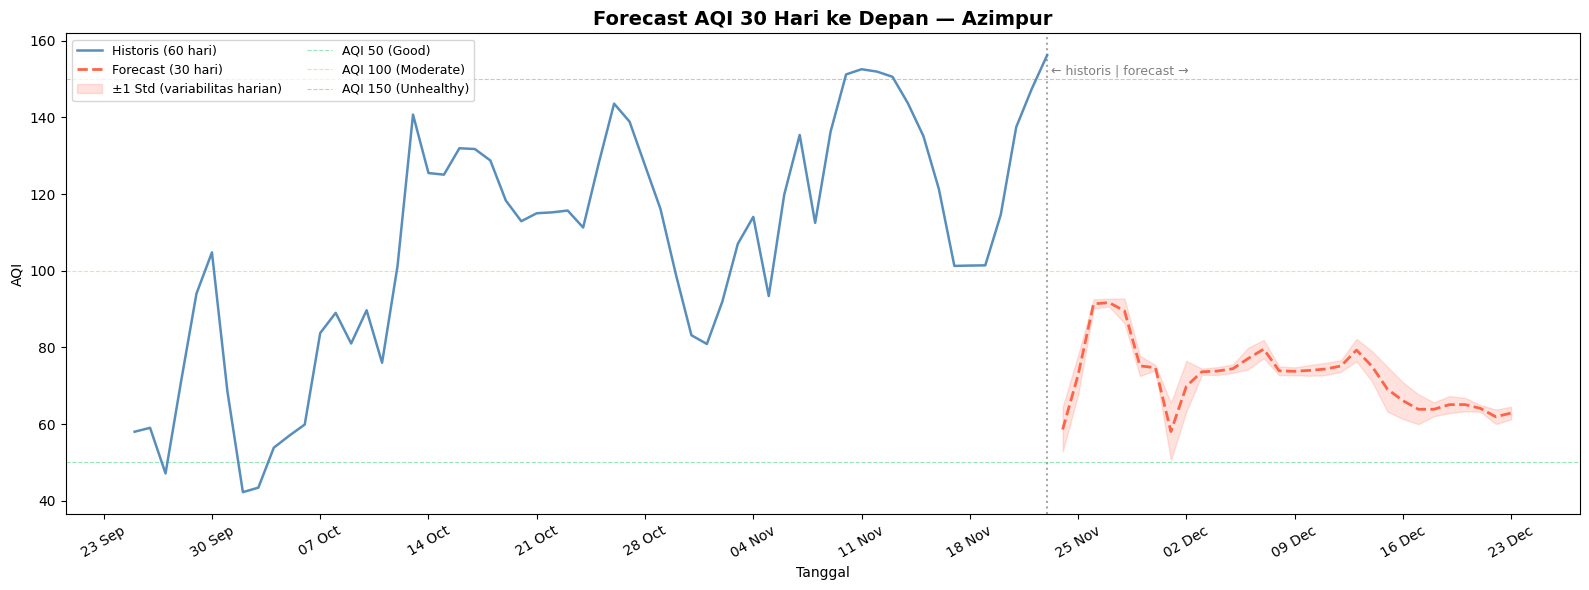

In [34]:
# ── Plot utama: Historis + Forecast 30 hari ──────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Historis
ax.plot(last60['date'], last60['aqi'],
        label='Historis (60 hari)', color='steelblue',
        linewidth=1.8, alpha=0.9, zorder=3)

# Forecast — dengan confidence band dari std
dates_fc = df_daily_forecast['date']
mean_fc  = df_daily_forecast['aqi_mean']
std_fc   = df_daily_forecast['aqi_std'].fillna(0)

ax.plot(dates_fc, mean_fc,
        label='Forecast (30 hari)', color='tomato',
        linewidth=2, linestyle='--', zorder=4)
ax.fill_between(dates_fc,
                np.clip(mean_fc - std_fc, 0, None),
                mean_fc + std_fc,
                alpha=0.18, color='tomato', label='±1 Std (variabilitas harian)')

# Garis pemisah historis/forecast
ax.axvline(last60['date'].iloc[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(last60['date'].iloc[-1], ax.get_ylim()[1]*0.95,
        ' ← historis | forecast →', fontsize=9, color='gray', va='top')

# Threshold AQI
ax.axhline(50,  color='#2ecc71', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 50 (Good)')
ax.axhline(100, color='#f1c40f', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 100 (Moderate)')
ax.axhline(150, color='#e67e22', linestyle='--', linewidth=0.8, alpha=0.5, label='AQI 150 (Unhealthy)')

ax.set_title(f'Forecast AQI 30 Hari ke Depan — {top_city}',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Tanggal'); ax.set_ylabel('AQI')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

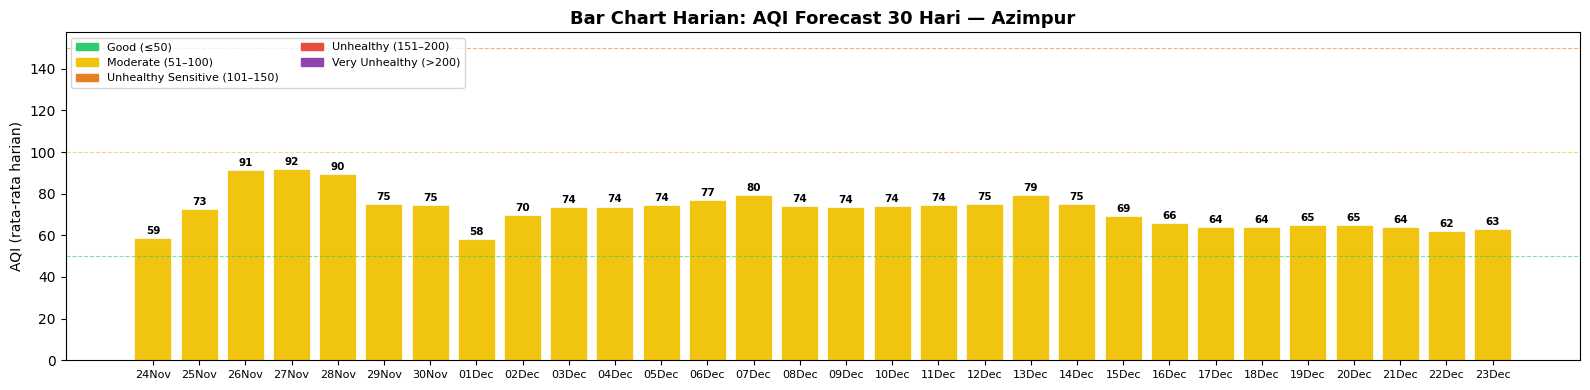

In [35]:
# ── Kalender heatmap forecast ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

colors = [aqi_color(v) for v in df_daily_forecast['aqi_mean']]
x_pos  = np.arange(len(df_daily_forecast))

bars = ax.bar(x_pos, df_daily_forecast['aqi_mean'],
              color=colors, edgecolor='white', linewidth=0.5, width=0.8)

# Label nilai di atas bar
for bar, val in zip(bars, df_daily_forecast['aqi_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# X-axis: tampilkan tanggal
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [d.strftime('%d%b') for d in df_daily_forecast['date']],
    fontsize=8
)

# Threshold lines
for thresh, label, color in [(50,'Good','#2ecc71'), (100,'Moderate','#f1c40f'),
                              (150,'Unhealthy','#e67e22')]:
    ax.axhline(thresh, color=color, linestyle='--', linewidth=0.8, alpha=0.6, label=label)

ax.set_title(f'Bar Chart Harian: AQI Forecast 30 Hari — {top_city}', fontweight='bold', fontsize=13)
ax.set_ylabel('AQI (rata-rata harian)')
ax.legend(fontsize=9, loc='upper right')

# Legend kategori warna
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#2ecc71', label='Good (≤50)'),
    Patch(color='#f1c40f', label='Moderate (51–100)'),
    Patch(color='#e67e22', label='Unhealthy Sensitive (101–150)'),
    Patch(color='#e74c3c', label='Unhealthy (151–200)'),
    Patch(color='#8e44ad', label='Very Unhealthy (>200)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8, ncol=2)

plt.tight_layout(); plt.show()

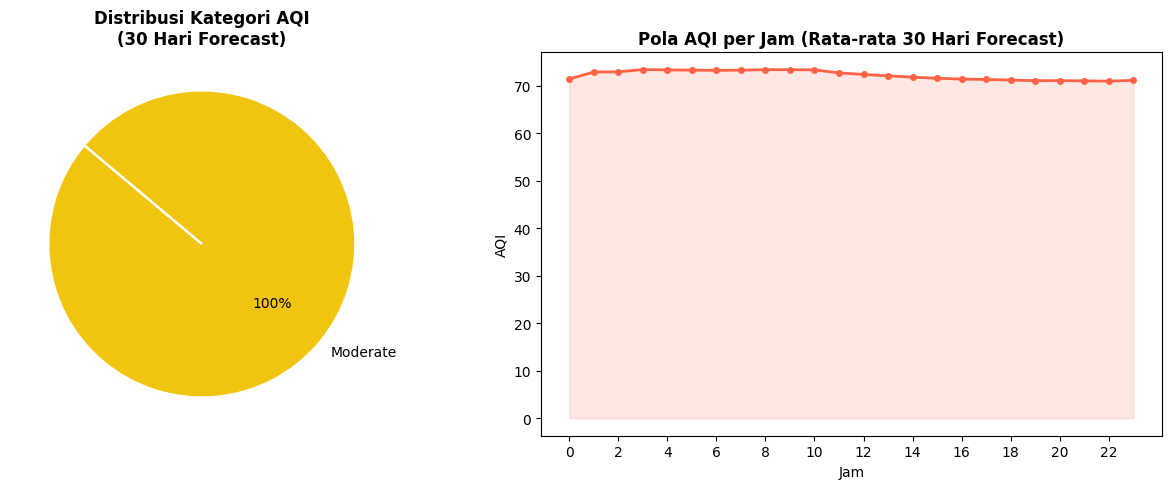

In [36]:
# ── Distribusi kategori AQI selama 30 hari ───────────────────────────────────
def aqi_cat_label(v):
    if v <= 50:    return 'Good'
    elif v <= 100: return 'Moderate'
    elif v <= 150: return 'Unhealthy (Sensitive)'
    elif v <= 200: return 'Unhealthy'
    else:          return 'Very Unhealthy'

df_daily_forecast['category'] = df_daily_forecast['aqi_mean'].apply(aqi_cat_label)
cat_counts = df_daily_forecast['category'].value_counts()

cat_color_map = {
    'Good': '#2ecc71',
    'Moderate': '#f1c40f',
    'Unhealthy (Sensitive)': '#e67e22',
    'Unhealthy': '#e74c3c',
    'Very Unhealthy': '#8e44ad'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
pie_colors = [cat_color_map.get(c, 'gray') for c in cat_counts.index]
axes[0].pie(cat_counts.values, labels=cat_counts.index, colors=pie_colors,
            autopct='%1.0f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Distribusi Kategori AQI\n(30 Hari Forecast)', fontweight='bold')

# Hourly forecast pattern
df_forecast['hour'] = df_forecast['datetime'].dt.hour
hourly_fc = df_forecast.groupby('hour')['aqi_pred'].mean()
axes[1].plot(hourly_fc.index, hourly_fc.values,
             color='tomato', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(hourly_fc.index, hourly_fc.values, alpha=0.15, color='tomato')
axes[1].set_title('Pola AQI per Jam (Rata-rata 30 Hari Forecast)', fontweight='bold')
axes[1].set_xlabel('Jam'); axes[1].set_ylabel('AQI')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout(); plt.show()

## 13. Ringkasan Hasil & Export

In [37]:
# ── Ringkasan lengkap ────────────────────────────────────────────────────────
print("=" * 65)
print("          RINGKASAN HASIL LSTM FORECASTING AQI")
print("=" * 65)
print(f"  Kota          : {top_city}")
print(f"  Data          : Hourly, 6 bulan terakhir ({len(df_model):,} record)")
print(f"  Fitur LSTM    : {n_features} fitur")
print(f"  LOOK_BACK     : {LOOK_BACK} jam ({LOOK_BACK // 24} hari)")
print(f"  Horizon       : {FORECAST_HOURS} jam (30 hari)")
print()
print("  Performa Model (Test Set):")
print(f"  {'Metrik':<10} {'Nilai':>10}")
print(f"  {'-'*24}")
for k, v in test_metrics.items():
    if k == 'Model':
        continue
    unit = '%' if k == 'MAPE' else ''
    print(f"  {k:<10} {v:>9.4f}{unit}")
print()
print("  Forecast Ringkasan (30 Hari):")
print(f"  AQI rata-rata  : {df_daily_forecast['aqi_mean'].mean():.2f}")
print(f"  AQI minimum    : {df_daily_forecast['aqi_min'].min():.2f}")
print(f"  AQI maksimum   : {df_daily_forecast['aqi_max'].max():.2f}")
print()
print("  Distribusi Kategori Forecast:")
for cat, cnt in cat_counts.items():
    print(f"    {cat:<28} : {cnt:>2} hari")
print("=" * 65)

          RINGKASAN HASIL LSTM FORECASTING AQI
  Kota          : Azimpur
  Data          : Hourly, 6 bulan terakhir (128,093 record)
  Fitur LSTM    : 95 fitur
  LOOK_BACK     : 48 jam (2 hari)
  Horizon       : 720 jam (30 hari)

  Performa Model (Test Set):
  Metrik          Nilai
  ------------------------
  MAE          55.8052
  RMSE         65.3592
  R2           -2.0840
  MAPE         42.3920%

  Forecast Ringkasan (30 Hari):
  AQI rata-rata  : 72.26
  AQI minimum    : 48.56
  AQI maksimum   : 92.95

  Distribusi Kategori Forecast:
    Moderate                     : 30 hari


In [38]:
# ── Export forecast harian ke CSV ─────────────────────────────────────────────
df_export = df_daily_forecast[['date', 'aqi_mean', 'aqi_min', 'aqi_max', 'aqi_std', 'category']].copy()
df_export.columns = ['Tanggal', 'AQI_Mean', 'AQI_Min', 'AQI_Max', 'AQI_Std', 'Kategori']
df_export.to_csv('results/forecast_aqi_30hari.csv', index=False)
print("✅ Forecast disimpan ke 'results/forecast_aqi_30hari.csv'")
print()
print(df_export.to_string(index=False))

✅ Forecast disimpan ke 'results/forecast_aqi_30hari.csv'

   Tanggal  AQI_Mean   AQI_Min   AQI_Max  AQI_Std Kategori
2025-11-24 58.582219 48.556952 70.868538 5.794060 Moderate
2025-11-25 72.795126 58.994894 78.401785 5.195922 Moderate
2025-11-26 91.348146 87.285136 92.631035 1.188964 Moderate
2025-11-27 91.682529 88.786577 92.945342 1.023951 Moderate
2025-11-28 89.524707 84.070735 92.651759 3.211007 Moderate
2025-11-29 75.177797 72.415493 84.028409 2.644083 Moderate
2025-11-30 74.691406 73.724811 75.875096 0.684964 Moderate
2025-12-01 58.037065 53.548358 75.409608 7.457226 Moderate
2025-12-02 69.859276 55.137883 76.598172 6.609294 Moderate
2025-12-03 73.629988 70.947932 75.980990 0.818617 Moderate
2025-12-04 73.824121 70.195584 75.995652 1.012759 Moderate
2025-12-05 74.435370 73.212908 76.306270 1.089658 Moderate
2025-12-06 77.106871 73.722301 80.924104 2.836206 Moderate
2025-12-07 79.540244 74.344949 81.523286 2.378820 Moderate
2025-12-08 73.889641 73.227553 78.689484 1.118957 Moderat

In [39]:
# ── Export forecast per jam ke CSV ────────────────────────────────────────────
df_forecast_export = df_forecast[['datetime', 'aqi_pred']].copy()
df_forecast_export['kategori'] = df_forecast_export['aqi_pred'].apply(aqi_cat_label)
df_forecast_export.to_csv('results/forecast_aqi_hourly_30hari.csv', index=False)
print("✅ Forecast per jam disimpan ke 'results/forecast_aqi_hourly_30hari.csv'")
print(f"   Total baris: {len(df_forecast_export):,}")

✅ Forecast per jam disimpan ke 'results/forecast_aqi_hourly_30hari.csv'
   Total baris: 720


In [40]:
# ── Simpan model & scaler ─────────────────────────────────────────────────────
import joblib

lstm_model.save('models/lstm_aqi_model.h5')

# Prefix "lstm_" agar tidak bentrok dengan robust_scaler.pkl dari nb04
joblib.dump(scaler_X, 'artifacts/lstm_scaler_X.pkl')
joblib.dump(scaler_y, 'artifacts/lstm_scaler_y.pkl')

print("✅ Model & scaler tersimpan:")
print("   models/lstm_aqi_model.h5      — model LSTM")
print("   artifacts/lstm_scaler_X.pkl   — scaler fitur (RobustScaler)")
print("   artifacts/lstm_scaler_y.pkl   — scaler target AQI (MinMaxScaler)")
print()
print("Untuk load ulang:")
print("  model    = tf.keras.models.load_model('models/lstm_aqi_model.h5')")
print("  scaler_X = joblib.load('artifacts/lstm_scaler_X.pkl')")
print("  scaler_y = joblib.load('artifacts/lstm_scaler_y.pkl')")

✅ Model & scaler tersimpan:
   models/lstm_aqi_model.h5      — model LSTM
   artifacts/lstm_scaler_X.pkl   — scaler fitur (RobustScaler)
   artifacts/lstm_scaler_y.pkl   — scaler target AQI (MinMaxScaler)

Untuk load ulang:
  model    = tf.keras.models.load_model('models/lstm_aqi_model.h5')
  scaler_X = joblib.load('artifacts/lstm_scaler_X.pkl')
  scaler_y = joblib.load('artifacts/lstm_scaler_y.pkl')


## Catatan Akhir

### Interpretasi Hasil
- **MAE / RMSE** yang rendah menunjukkan model mampu mengikuti pola AQI per jam dengan baik
- **R²** mendekati 1 menunjukkan model menjelaskan sebagian besar variansi AQI
- **Forecast 30 hari** bersifat **indikatif** — semakin jauh horizon, semakin besar akumulasi error (karena carry-forward polutan)

### Keterbatasan & Future Work
| Keterbatasan | Solusi Potensial |
|---|---|
| Polutan masa depan tidak diketahui (carry-forward) | Integrasikan data prakiraan cuaca / NWP |
| Forecast tidak per-kota (satu seed sequence global) | City-specific seed sequence untuk forecast yang lebih akurat |
| Recursive forecasting accumulates error | Direct multi-output LSTM (prediksi 720 langkah sekaligus) |
| Tidak ada hyperparameter tuning | Optuna / KerasTuner |